In [13]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import subprocess

matplotlib.rcParams.update({"axes.grid": True})
# matplotlib.rcParams.keys()

In [14]:
compile = subprocess.run(
    ["./compile_project"],
    capture_output=True,
    text=True
)

print(compile.stdout)
print(compile.stderr)

-- Configuring done (0.0s)
-- Generating done (0.0s)
-- Build files have been written to: /home/davide/GitHub/computational_physics_2_2026/variational-monte-carlo-fys4411-DC2026/build
[  7%] Linking CXX executable vmc
[100%] Built target vmc

mkdir: cannot create directory ‘build’: File exists



Analytic if available

In [15]:
result = subprocess.run(
    ["./vmc", "true"],
    capture_output=True,
    text=True
)

print(result.stdout)
print(result.stderr)


  -- System info -- 
 Number of particles  : 1
 Number of dimensions : 3
 Number of Metropolis steps run : 10^6
 Step length used : 0.05
 Ratio of accepted steps: 0.879318
 Elapsed time: 3 s

  -- Wave function parameters -- 
 Number of parameters : 2
 Parameter 1 : 0.3
 Parameter 2 : 1

  -- Results -- 
 Energy : 1.70133
 Variance : 0.428694
 Error : 0.654748


  -- System info -- 
 Number of particles  : 1
 Number of dimensions : 3
 Number of Metropolis steps run : 10^6
 Step length used : 0.05
 Ratio of accepted steps: 0.860555
 Elapsed time: 2 s

  -- Wave function parameters -- 
 Number of parameters : 2
 Parameter 1 : 0.4
 Parameter 2 : 1

  -- Results -- 
 Energy : 1.53787
 Variance : 0.0764168
 Error : 0.276436


  -- System info -- 
 Number of particles  : 1
 Number of dimensions : 3
 Number of Metropolis steps run : 10^6
 Step length used : 0.05
 Ratio of accepted steps: 0.844001
 Elapsed time: 2 s

  -- Wave function parameters -- 
 Number of parameters : 2
 Parameter 1 : 0

Text(0.5, 0, '$\\alpha$')

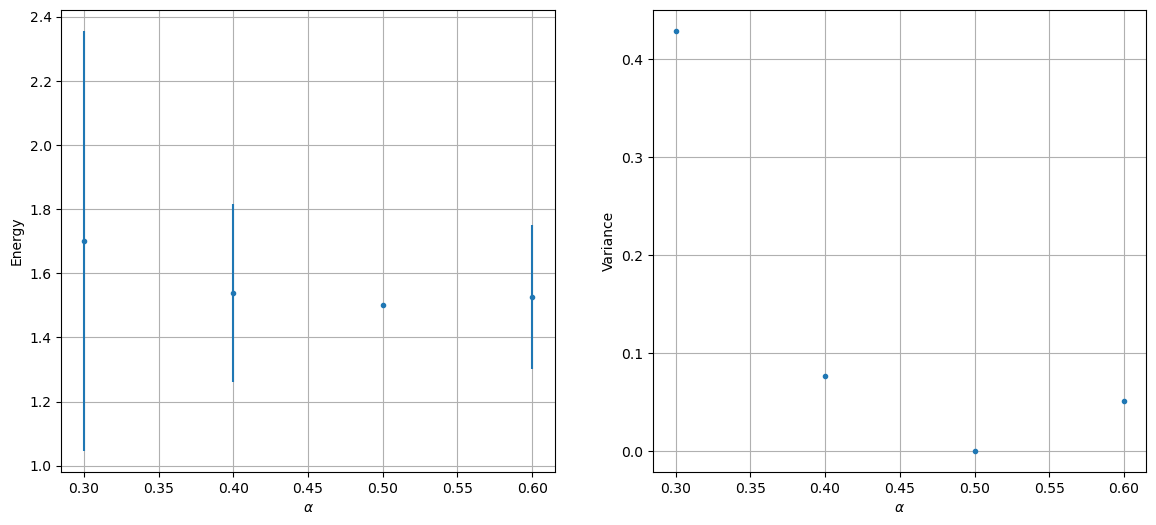

In [ ]:
file = np.loadtxt("iofiles/output.csv", delimiter=',')
file = np.transpose(file)
parameters = file[:file.shape[0] - 3, :]
energy = file[file.shape[0] - 3, :]
variance = file[file.shape[0] - 2, :]
error = file[file.shape[0] - 1, :]

fig = plt.figure(figsize=(14,6))
gs = fig.add_gridspec(1,2)
ax = fig.add_subplot(gs[0, 0])
ax.errorbar(parameters[0, :], energy, error, ls="none", marker='.')
ax.set_ylabel("Energy")
ax.set_xlabel(r"$\alpha$")
ax = fig.add_subplot(gs[0, 1])
ax.errorbar(parameters[0, :], variance, ls="none", marker='.')
ax.set_ylabel("Variance")
ax.set_xlabel(r"$\alpha$")

Numerical

In [17]:
result = subprocess.run(
    ["./vmc", "false"],
    capture_output=True,
    text=True
)

print(result.stdout)
print(result.stderr)


  -- System info -- 
 Number of particles  : 1
 Number of dimensions : 3
 Number of Metropolis steps run : 10^6
 Step length used : 0.05
 Ratio of accepted steps: 0.879318
 Elapsed time: 3 s

  -- Wave function parameters -- 
 Number of parameters : 2
 Parameter 1 : 0.3
 Parameter 2 : 1

  -- Results -- 
 Energy : 1.70133
 Variance : 0.428694
 Error : 0.654748


  -- System info -- 
 Number of particles  : 1
 Number of dimensions : 3
 Number of Metropolis steps run : 10^6
 Step length used : 0.05
 Ratio of accepted steps: 0.860555
 Elapsed time: 2 s

  -- Wave function parameters -- 
 Number of parameters : 2
 Parameter 1 : 0.4
 Parameter 2 : 1

  -- Results -- 
 Energy : 1.53787
 Variance : 0.0764168
 Error : 0.276436


  -- System info -- 
 Number of particles  : 1
 Number of dimensions : 3
 Number of Metropolis steps run : 10^6
 Step length used : 0.05
 Ratio of accepted steps: 0.844001
 Elapsed time: 3 s

  -- Wave function parameters -- 
 Number of parameters : 2
 Parameter 1 : 0

[1.70133364 1.53786955 1.5        1.52459445]


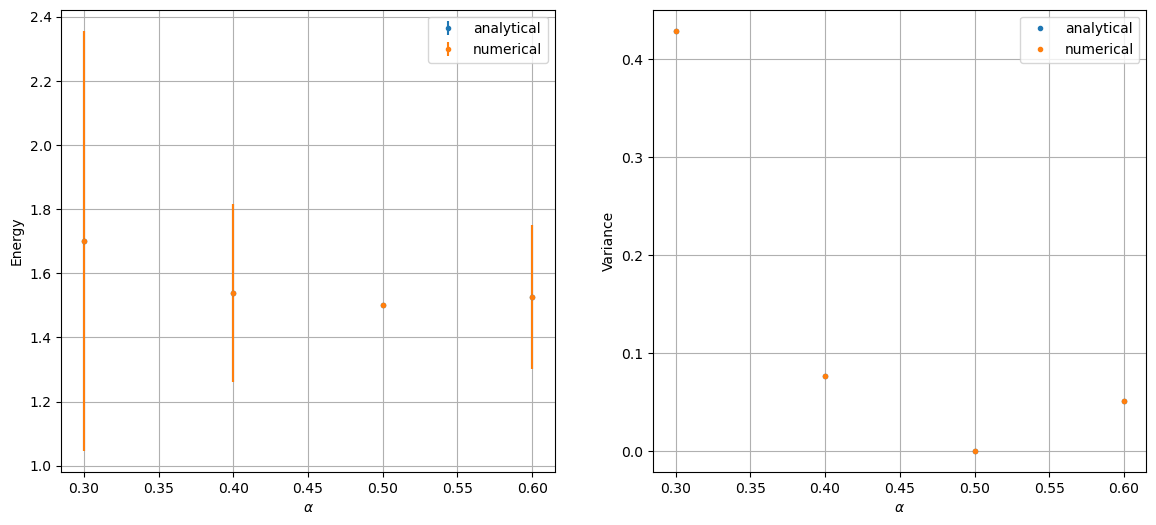

In [18]:
num_file = np.loadtxt("iofiles/output.csv", delimiter=',')
num_file = np.transpose(num_file)
num_parameters = num_file[:file.shape[0] - 3, :]
num_energy = num_file[num_file.shape[0] - 3, :]
num_variance = num_file[num_file.shape[0] - 2, :]
num_error = num_file[num_file.shape[0] - 1, :]

fig = plt.figure(figsize=(14,6))
gs = fig.add_gridspec(1,2)
ax = fig.add_subplot(gs[0, 0])
ax.errorbar(parameters[0, :], energy, error, ls="none", marker='.', label="analytical")
ax.errorbar(num_parameters[0, :], num_energy,num_error, ls="none", marker='.', label="numerical")
ax.set_ylabel("Energy")
ax.set_xlabel(r"$\alpha$")
ax.legend()
ax = fig.add_subplot(gs[0, 1])
ax.errorbar(parameters[0, :], variance, ls="none", marker='.', label="analytical")
ax.errorbar(num_parameters[0, :], num_variance, ls="none", marker='.', label="numerical")
ax.set_ylabel("Variance")
ax.set_xlabel(r"$\alpha$")
ax.legend()
print(energy)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


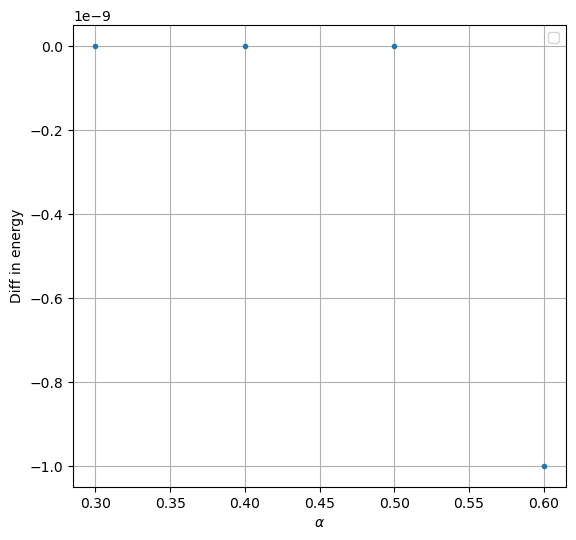

In [19]:
fig = plt.figure(figsize=(14,6))
gs = fig.add_gridspec(1,2)
ax = fig.add_subplot(gs[0, 0])
ax.errorbar(parameters[0, :], num_energy - energy, ls="none", marker='.')
ax.set_ylabel("Diff in energy")
ax.set_xlabel(r"$\alpha$")
ax.legend()